# Relatório de Resultados – Atualização (v4_clean)

Este notebook **não treina modelos**. Ele **consome a pasta `results/`** gerada pelo experimento e exporta:

- Tabelas (CSV + LaTeX) compatíveis com o Capítulo 5
- Figuras (PNG) compatíveis com as Figuras 5.1–5.6
- (Opcional) Tabela 5.5 e Figuras 5.7–5.8, **se** o artefato `edge_data_v4_clean.pt` estiver disponível

Data: 2026-01-09


In [ ]:
# Instalação mínima (funciona mesmo sem wheels extras)
!pip -q install torch_geometric

import torch
import torch_geometric

print("torch:", torch.__version__)
print("cuda :", torch.version.cuda)
print("pyg  :", torch_geometric.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.7 MB/s eta 0:00:00
torch: 2.9.0+cpu
cuda : None
pyg  : 2.7.0


In [ ]:
from pathlib import Path
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, re, subprocess
from pathlib import Path

# ====== CONFIG: ajuste o caminho do seu projeto ======
# Tenta montar Drive se estiver no Colab (opcional)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("[WARN] Não consegui montar o Drive:", repr(e))

BASE = Path("/content/drive/MyDrive") if IN_COLAB else Path(".").resolve()

PROJECT_DIR = BASE / "DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k"  # <-- AJUSTE AQUI
DATA_DIR    = PROJECT_DIR

RESULTS_DIR = PROJECT_DIR / "results"
PLOTS_DIR   = PROJECT_DIR / "plots"
ARTIF_DIR   = PROJECT_DIR / "artifacts"
# === Ajuste aqui ===
BASE_DIR = Path(".")  # ou Path("/content") no Colab
#RESULTS_DIR = BASE_DIR / "results"  # deve conter results_v4_clean.csv e purity_v4_clean.csv
PROBS_DIR   = RESULTS_DIR / "probs_v4"  # npz por modelo/semente
OUTPUT_DIR  = BASE_DIR / "thesis_exports_v4_clean"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(exist_ok=True)

# Seleções para gerar curvas/figuras (Figura 5.1–5.5)
MODEL_PLOT = "SAGE"
SEED_PLOT  = 44  # por padrão, o melhor seed no seu último run

# Opcional (para Tabela 5.5 e Figuras 5.7–5.8):
ARTIFACT_PATH = None
# Exemplo (Colab/Drive):
#ARTIFACT_PATH = "/content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/artifacts/edge_data_v4_clean.pt"

print("RESULTS_DIR:", RESULTS_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RESULTS_DIR: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/results
OUTPUT_DIR: /content/thesis_exports_v4_clean


In [ ]:
# Carrega resultados agregados
results_csv = RESULTS_DIR / "results_v4_clean.csv"
purity_csv  = RESULTS_DIR / "purity_v4_clean.csv"



df = pd.read_csv(results_csv)
pur = pd.read_csv(purity_csv)

display(df.head())
display(pur.head())

print("Modelos:", df['model'].unique())
print("Seeds:", sorted(df['seed'].unique()))
print("Test pos_rate (fixo):", df['test_pos_rate'].iloc[0])
print("Test n_edges (fixo):", int(df['test_n_edges'].iloc[0]))


,model,seed,setting,params,best_epoch,best_val_score,train_seconds,rss_gb_start,rss_gb_end,gpu_peak_gb,...,test_pos_rate,test_n_edges,test_thr_Prec,test_thr_Recall,test_thr_F1,test_thr_FAR,test_purity_macro_selected@1%,test_purity_weighted_selected@1%,test_purity_macro_induced@1%,test_purity_weighted_induced@1%
0,SAGE,42,temporal,17857.0,200.0,0.761989,216.508955,6.704323,7.224331,2.416155,...,0.001433,2490609,0.936170,0.714846,0.810673,0.000070,0.411640,0.141179,0.170936,0.072473
1,GATv2,42,temporal,18241.0,200.0,0.707417,240.421962,7.164436,7.302555,17.540371,...,0.001433,2490609,0.956031,0.663866,0.783601,0.000044,0.559393,0.119331,0.235488,0.074266
2,GINE,42,temporal,21977.0,190.0,0.050638,218.932866,7.252975,7.334652,7.916795,...,0.001433,2490609,0.187472,0.119048,0.145623,0.000741,0.284074,0.038431,0.142134,0.023314
3,PNA,42,temporal,92125.0,5.0,0.082902,77.762717,7.283421,7.349949,32.357498,...,0.001433,2490609,0.532143,0.083473,0.144310,0.000105,0.092561,0.047144,0.070615,0.029111
4,SAGE,43,temporal,17857.0,195.0,0.804224,217.231435,7.296104,7.349590,2.416155,...,0.001433,2490609,0.921939,0.750980,0.827725,0.000091,0.424874,0.136007,0.179821,0.074248


,k%,n_groups,purity_macro_selected,purity_weighted_selected,purity_macro_induced,purity_weighted_induced,edges_in_groups_induced,pos_in_groups_induced,model,seed
0,1.0,1200,0.411640,0.141179,0.170936,0.072473,43409,3146,SAGE,42
1,2.0,1157,0.285133,0.068201,0.120810,0.030909,104500,3230,SAGE,42
2,5.0,533,0.184599,0.026274,0.078480,0.008412,406420,3419,SAGE,42
3,10.0,196,0.058642,0.013244,0.027878,0.003999,876680,3506,SAGE,42
4,1.0,855,0.559393,0.119331,0.235488,0.074266,40382,2999,GATv2,42


Modelos: ['SAGE' 'GATv2' 'GINE' 'PNA' 'MLP' 'XGBoost' 'LightGBM']
Seeds: [np.int64(42), np.int64(43), np.int64(44)]
Test pos_rate (fixo): 0.0014333843650287
Test n_edges (fixo): 2490609


In [ ]:
# Helpers de formatação (pt-BR)
def fmt(x, nd=3):
    if pd.isna(x):
        return ""
    return f"{x:.{nd}f}".replace(".", ",")

def fmt_pct(x, nd=1):
    return f"{100*x:.{nd}f}%".replace(".", ",")

def mean_std_str(mean, std, nd=3):
    return f"{mean:.{nd}f} ± {std:.{nd}f}".replace(".", ",")

MODEL_LABEL = {
    "SAGE": "GraphSAGE",
    "GATv2": "GATv2",
    "GINE": "GINE",
    "MLP": "MLP (baseline)"
}
MODEL_ORDER = ["SAGE","MLP","GATv2","GINE"]


In [ ]:
# ===== Tabela 5.1 (comparação de arquiteturas) =====
cols = ["test_AUC","test_AP","test_R@2%","test_R@5%","test_R@10%"]

# Versão 1: seed fixo (SEED_PLOT)
df_seed = df[df.seed==SEED_PLOT].set_index("model").loc[MODEL_ORDER].reset_index()
t51_seed = df_seed[["model"]+cols].copy()
t51_seed["Arquitetura"] = t51_seed["model"].map(MODEL_LABEL)
t51_seed = t51_seed.drop(columns=["model"])
t51_seed = t51_seed[["Arquitetura"]+cols]
t51_seed.columns = ["Arquitetura","AUC","AP","Recall@2%","Recall@5%","Recall@10%"]

t51_seed_fmt = t51_seed.copy()
for c in t51_seed_fmt.columns[1:]:
    t51_seed_fmt[c] = t51_seed_fmt[c].map(lambda x: fmt(x,3))

# Versão 2: média ± dp (3 seeds)
summary = df.groupby("model")[cols].agg(["mean","std"]).loc[MODEL_ORDER]
t51_mean = pd.DataFrame({"Arquitetura":[MODEL_LABEL[m] for m in MODEL_ORDER]})
for c in cols:
    t51_mean[c] = [mean_std_str(summary.loc[m,(c,"mean")], summary.loc[m,(c,"std")], nd=3) for m in MODEL_ORDER]
t51_mean.columns = ["Arquitetura","AUC (m±dp)","AP (m±dp)","Recall@2% (m±dp)","Recall@5% (m±dp)","Recall@10% (m±dp)"]

# Exporta
t51_seed_fmt.to_csv(OUTPUT_DIR/"tables"/"Tabela_5_1_seed.csv", index=False)
(OUTPUT_DIR/"tables"/"Tabela_5_1_seed.tex").write_text(t51_seed_fmt.to_latex(index=False, escape=False), encoding="utf-8")

t51_mean.to_csv(OUTPUT_DIR/"tables"/"Tabela_5_1_media_dp.csv", index=False)
(OUTPUT_DIR/"tables"/"Tabela_5_1_media_dp.tex").write_text(t51_mean.to_latex(index=False, escape=False), encoding="utf-8")

display(t51_seed_fmt)
display(t51_mean)


,Arquitetura,AUC,AP,Recall@2%,Recall@5%,Recall@10%
0,GraphSAGE,"0,984","0,783","0,889","0,904","0,924"
1,MLP (baseline),"0,972","0,785","0,876","0,894","0,914"
2,GATv2,"0,977","0,698","0,841","0,883","0,912"
3,GINE,"0,916","0,078","0,355","0,491","0,629"


,Arquitetura,AUC (m±dp),AP (m±dp),Recall@2% (m±dp),Recall@5% (m±dp),Recall@10% (m±dp)
0,GraphSAGE,"0,983 ± 0,001","0,790 ± 0,016","0,887 ± 0,003","0,903 ± 0,004","0,923 ± 0,002"
1,MLP (baseline),"0,970 ± 0,001","0,796 ± 0,014","0,879 ± 0,004","0,897 ± 0,005","0,914 ± 0,003"
2,GATv2,"0,979 ± 0,002","0,715 ± 0,016","0,855 ± 0,013","0,890 ± 0,007","0,916 ± 0,004"
3,GINE,"0,917 ± 0,001","0,061 ± 0,028","0,344 ± 0,021","0,497 ± 0,007","0,648 ± 0,023"


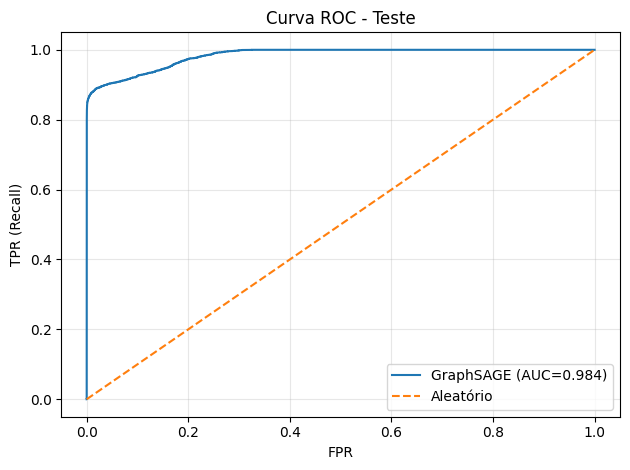

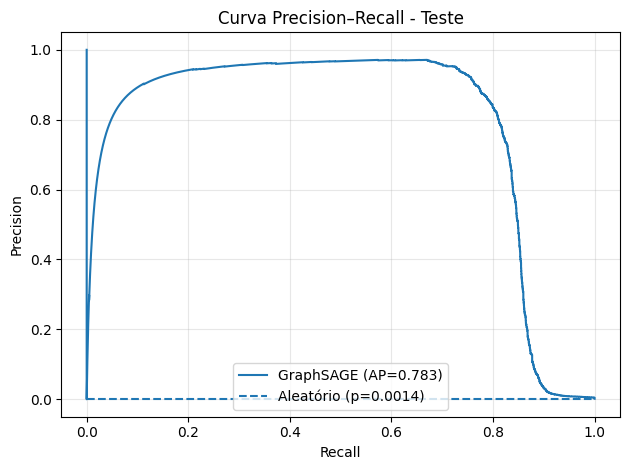

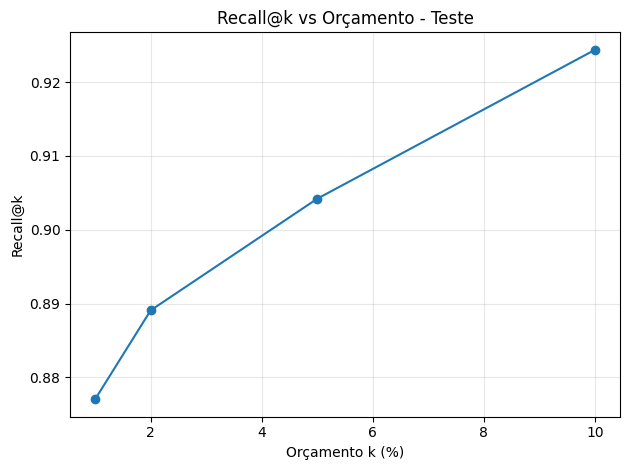

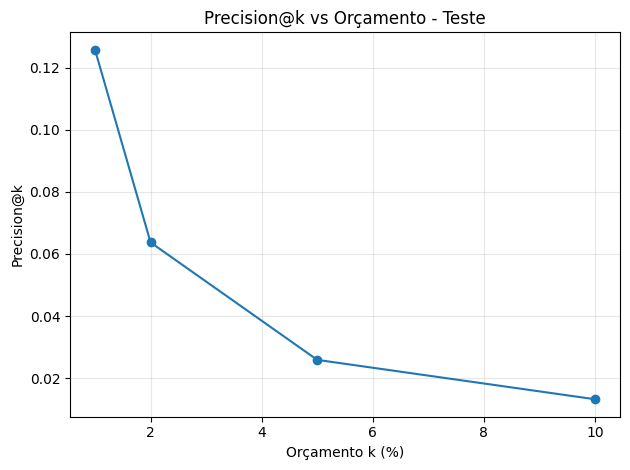

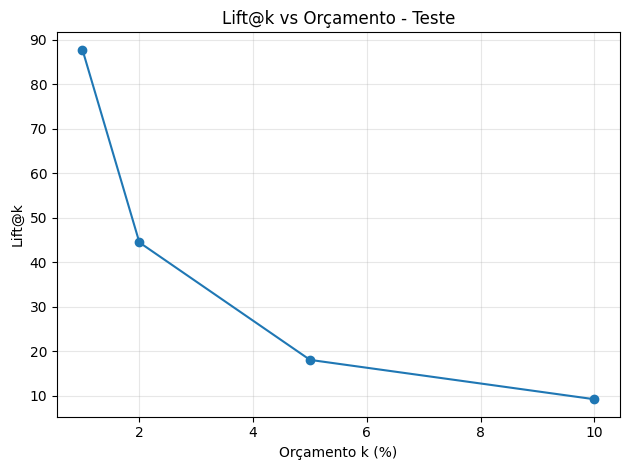

In [ ]:
# ===== Figuras 5.1–5.5 (GraphSAGE por padrão) =====
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

npz_path = PROBS_DIR / f"{MODEL_PLOT}_seed{SEED_PLOT}_test.npz"
npz = np.load(npz_path)
y = npz["y"].astype(int)
p = npz["p"]

# ROC
fpr, tpr, _ = roc_curve(y, p)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"{MODEL_LABEL.get(MODEL_PLOT, MODEL_PLOT)} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],"--", label="Aleatório")
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC - Teste")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figures"/"Figura_5_1_ROC.png", dpi=200)
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y, p)
ap = average_precision_score(y, p)
baseline = y.mean()
plt.figure()
plt.plot(rec, prec, label=f"{MODEL_LABEL.get(MODEL_PLOT, MODEL_PLOT)} (AP={ap:.3f})")
plt.hlines(baseline, 0, 1, linestyles="--", label=f"Aleatório (p={baseline:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall - Teste")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figures"/"Figura_5_2_PR.png", dpi=200)
plt.show()

# Curvas top-k (pontos em k={1,2,5,10})
row = df.query("model==@MODEL_PLOT and seed==@SEED_PLOT").iloc[0]
ks = [1,2,5,10]
rec_k  = [float(row[f"test_R@{k}%"]) for k in ks]
prec_k = [float(row[f"test_P@{k}%"]) for k in ks]
lift_k = [float(row[f"test_L@{k}%"]) for k in ks]

plt.figure()
plt.plot(ks, rec_k, marker="o")
plt.xlabel("Orçamento k (%)")
plt.ylabel("Recall@k")
plt.title("Recall@k vs Orçamento - Teste")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figures"/"Figura_5_3_Recall_k.png", dpi=200)
plt.show()

plt.figure()
plt.plot(ks, prec_k, marker="o")
plt.xlabel("Orçamento k (%)")
plt.ylabel("Precision@k")
plt.title("Precision@k vs Orçamento - Teste")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figures"/"Figura_5_4_Precision_k.png", dpi=200)
plt.show()

plt.figure()
plt.plot(ks, lift_k, marker="o")
plt.xlabel("Orçamento k (%)")
plt.ylabel("Lift@k")
plt.title("Lift@k vs Orçamento - Teste")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figures"/"Figura_5_5_Lift_k.png", dpi=200)
plt.show()


In [ ]:
# ===== Tabela 5.2 e 5.3 (GraphSAGE por padrão) =====
E_test = int(row["test_n_edges"])
pos_total = int(round(float(row["test_pos_rate"]) * E_test))
ks = [1,2,5,10]

# Tabela 5.2 (eficiência / retorno marginal)
rec_vals = [float(row[f"test_R@{k}%"]) for k in ks]
lift_vals = [float(row[f"test_L@{k}%"]) for k in ks]
delta = [None] + [rec_vals[i]-rec_vals[i-1] for i in range(1,len(ks))]
delta_per = [None] + [delta[i]/(ks[i]-ks[i-1]) for i in range(1,len(ks))]

t52 = pd.DataFrame({
    "Orçamento (k)": [f"{k}%" for k in ks],
    "Recall@k": rec_vals,
    "Lift@k": lift_vals,
    "ΔRecall": delta,
    "ΔRecall/Δk": delta_per
})
t52_fmt = t52.copy()
t52_fmt["Recall@k"] = t52_fmt["Recall@k"].map(lambda x: fmt(x,3))
t52_fmt["Lift@k"] = t52_fmt["Lift@k"].map(lambda x: fmt(x,1))
t52_fmt["ΔRecall"] = t52_fmt["ΔRecall"].map(lambda x: "" if pd.isna(x) else fmt(x,3))
t52_fmt["ΔRecall/Δk"] = t52_fmt["ΔRecall/Δk"].map(lambda x: "" if pd.isna(x) else fmt(x,3))

t52_fmt.to_csv(OUTPUT_DIR/"tables"/"Tabela_5_2.csv", index=False)
(OUTPUT_DIR/"tables"/"Tabela_5_2.tex").write_text(t52_fmt.to_latex(index=False, escape=False), encoding="utf-8")
display(t52_fmt)

# Tabela 5.3 (custo operacional)
rows_53=[]
for k in ks:
    k_edges = int(math.ceil((k/100)*E_test))
    rec = float(row[f"test_R@{k}%"])
    pos_rec = int(round(rec*pos_total))
    prec = float(row[f"test_P@{k}%"])
    ipi = (1/prec) if prec>0 else float("inf")
    rows_53.append({
        "k": f"{k}%",
        "Qtd. inspecionadas": k_edges,
        "Ilícitos recuperados": pos_rec,
        "Precision@k": prec,
        "Inspeções por ilícito": ipi
    })
t53 = pd.DataFrame(rows_53)
t53_fmt = t53.copy()
t53_fmt["Qtd. inspecionadas"] = t53_fmt["Qtd. inspecionadas"].map(lambda x: f"{x:,}".replace(",","."))
t53_fmt["Ilícitos recuperados"] = t53_fmt["Ilícitos recuperados"].map(lambda x: f"{x:,}".replace(",","."))
t53_fmt["Precision@k"] = t53_fmt["Precision@k"].map(lambda x: fmt_pct(x,2))
t53_fmt["Inspeções por ilícito"] = t53_fmt["Inspeções por ilícito"].map(lambda x: f"∼{int(round(x))}")

t53_fmt.to_csv(OUTPUT_DIR/"tables"/"Tabela_5_3.csv", index=False)
(OUTPUT_DIR/"tables"/"Tabela_5_3.tex").write_text(t53_fmt.to_latex(index=False, escape=False), encoding="utf-8")
display(t53_fmt)

print("pos_total (teste):", pos_total)


,Orçamento (k),Recall@k,Lift@k,ΔRecall,ΔRecall/Δk
0,1%,"0,877","87,7",,
1,2%,"0,889","44,5","0,012","0,012"
2,5%,"0,904","18,1","0,015","0,005"
3,10%,"0,924","9,2","0,020","0,004"


,k,Qtd. inspecionadas,Ilícitos recuperados,Precision@k,Inspeções por ilícito
0,1%,24.907,3.131,"12,57%",∼8
1,2%,49.813,3.174,"6,37%",∼16
2,5%,124.531,3.228,"2,59%",∼39
3,10%,249.061,3.300,"1,32%",∼75


pos_total (teste): 3570


,Orçamento k,Recall@k,Cobertura (casos),Pureza (casos induzidos),CR@k (intra-caso)
0,1%,"0,877","0,880","0,0761","0,996"
1,2%,"0,889","0,906","0,0330","0,981"
2,5%,"0,904","0,955","0,0074","0,946"
3,10%,"0,924","0,982","0,0038","0,942"


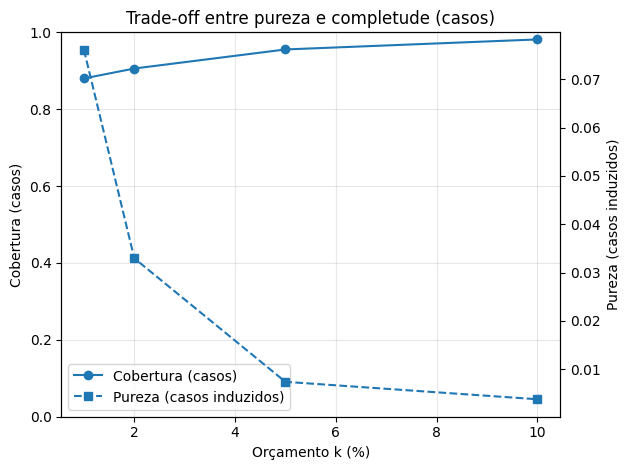

In [ ]:
# ===== Tabela 5.4 + Figura 5.6 (trade-off em nível de grupos) =====
# Observação: usa métricas de pureza (fração de ilícitos) calculadas em:
# - "selected": somente arestas selecionadas no top-k
# - "induced": subgrafo induzido por nós (todas as arestas do teste entre nós dos grupos)

pur_row = pur.query("model==@MODEL_PLOT and seed==@SEED_PLOT").sort_values("k%").copy()
pos_total_test = int(round(float(df['test_pos_rate'].iloc[0]) * int(df['test_n_edges'].iloc[0])))

rows=[]
for k in ks:
    r = pur_row[pur_row["k%"]==float(k)].iloc[0]
    recall_k = float(row[f"test_R@{k}%"])
    sel_pos = recall_k * pos_total_test
    coverage = float(r["pos_in_groups_induced"]) / pos_total_test
    purity_ind = float(r["purity_weighted_induced"])
    cr_intra = sel_pos / float(r["pos_in_groups_induced"])
    rows.append({
        "Orçamento k": f"{k}%",
        "Recall@k": recall_k,
        "Cobertura (casos)": coverage,
        "Pureza (casos induzidos)": purity_ind,
        "CR@k (intra-caso)": cr_intra
    })
t54 = pd.DataFrame(rows)
t54_fmt = t54.copy()
t54_fmt["Recall@k"] = t54_fmt["Recall@k"].map(lambda x: fmt(x,3))
t54_fmt["Cobertura (casos)"] = t54_fmt["Cobertura (casos)"].map(lambda x: fmt(x,3))
t54_fmt["Pureza (casos induzidos)"] = t54_fmt["Pureza (casos induzidos)"].map(lambda x: fmt(x,4))
t54_fmt["CR@k (intra-caso)"] = t54_fmt["CR@k (intra-caso)"].map(lambda x: fmt(x,3))

t54_fmt.to_csv(OUTPUT_DIR/"tables"/"Tabela_5_4.csv", index=False)
(OUTPUT_DIR/"tables"/"Tabela_5_4.tex").write_text(t54_fmt.to_latex(index=False, escape=False), encoding="utf-8")
display(t54_fmt)

# Figura 5.6: Cobertura vs Pureza (induzida)
k_vals = ks
coverage_vals = [float(t54.loc[i,"Cobertura (casos)"]) for i in range(len(t54))]
purity_vals   = [float(t54.loc[i,"Pureza (casos induzidos)"]) for i in range(len(t54))]

fig, ax1 = plt.subplots()
ax1.plot(k_vals, coverage_vals, marker="o", label="Cobertura (casos)")
ax1.set_xlabel("Orçamento k (%)")
ax1.set_ylabel("Cobertura (casos)")
ax1.set_ylim(0,1.0)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(k_vals, purity_vals, marker="s", linestyle="--", label="Pureza (casos induzidos)")
ax2.set_ylabel("Pureza (casos induzidos)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="best")
plt.title("Trade-off entre pureza e completude (casos)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"figures"/"Figura_5_6_tradeoff.png", dpi=200)
plt.show()


In [ ]:
# ===== Tabela extra (custo de treino) =====
cost_cols = ["params","train_seconds","gpu_peak_gb","rss_gb_start","rss_gb_end"]
t_cost = []
for m in MODEL_ORDER:
    sub = df[df.model==m]
    t_cost.append({
        "Arquitetura": MODEL_LABEL[m],
        "Parâmetros": int(sub["params"].iloc[0]),
        "Tempo de treino (s)": sub["train_seconds"].mean(),
        "Pico GPU (GiB)": sub["gpu_peak_gb"].mean(),
        "RSS RAM início (GiB)": sub["rss_gb_start"].mean(),
        "RSS RAM fim (GiB)": sub["rss_gb_end"].mean(),
    })
t_cost = pd.DataFrame(t_cost)

t_cost_fmt = t_cost.copy()
t_cost_fmt["Parâmetros"] = t_cost_fmt["Parâmetros"].map(lambda x: f"{x:,}".replace(",","."))
for c in ["Tempo de treino (s)","Pico GPU (GiB)","RSS RAM início (GiB)","RSS RAM fim (GiB)"]:
    t_cost_fmt[c] = t_cost_fmt[c].map(lambda x: fmt(x,1))

t_cost_fmt.to_csv(OUTPUT_DIR/"tables"/"Tabela_custo_treino.csv", index=False)
(OUTPUT_DIR/"tables"/"Tabela_custo_treino.tex").write_text(t_cost_fmt.to_latex(index=False, escape=False), encoding="utf-8")
display(t_cost_fmt)


,Arquitetura,Parâmetros,Tempo de treino (s),Pico GPU (GiB),RSS RAM início (GiB),RSS RAM fim (GiB)
0,GraphSAGE,17.857,"216,7","2,4","7,1","7,3"
1,MLP (baseline),70.145,"56,9","0,7","7,3","7,4"
2,GATv2,18.241,"241,7","17,5","7,3","7,3"
3,GINE,21.977,"220,5","7,9","7,3","7,4"


In [ ]:
# ===== (Opcional) Tabela 5.5 + Figuras 5.7–5.8 (estrutura do top-k) =====
# Requer: ARTIFACT_PATH apontando para edge_data_v4_clean.pt

if ARTIFACT_PATH is None:
    print("ARTIFACT_PATH não definido. Pule esta seção.")
else:
    import torch
    from torch.serialization import add_safe_globals
    from torch_geometric.data.data import DataEdgeAttr

    # Compatibilidade torch>=2.6 (weights_only default)
    add_safe_globals([DataEdgeAttr])

    data = torch.load(ARTIFACT_PATH, map_location="cpu", weights_only=False)
    te_idx = data["te_idx"] if isinstance(data, dict) and "te_idx" in data else getattr(data, "te_idx", None)
    edge_index = data["edge_index"] if isinstance(data, dict) and "edge_index" in data else getattr(data, "edge_index", None)
    y_all = data["y"] if isinstance(data, dict) and "y" in data else getattr(data, "y", None)

    assert te_idx is not None and edge_index is not None and y_all is not None, "Artefato não contém te_idx/edge_index/y"

    te_idx = te_idx.numpy() if hasattr(te_idx, "numpy") else np.array(te_idx)
    edge_index = edge_index.numpy() if hasattr(edge_index, "numpy") else np.array(edge_index)
    y_all = y_all.numpy() if hasattr(y_all, "numpy") else np.array(y_all)

    # Scores do teste (na mesma ordem de te_idx)
    npz = np.load(PROBS_DIR / f"{MODEL_PLOT}_seed{SEED_PLOT}_test.npz")
    p_test = npz["p"]
    y_test = npz["y"].astype(int)

    assert len(p_test) == len(te_idx) == len(y_test), "Inconsistência de tamanhos entre probs e te_idx"

    # Ranking
    order = np.argsort(-p_test)  # desc
    out_rows = []
    for k in ks:
        K = int(math.ceil((k/100) * len(te_idx)))
        sel_local = order[:K]
        sel_global_edges = te_idx[sel_local]  # índices no grafo total

        # Subgrafo edge-induced do top-k
        src = edge_index[0, sel_global_edges]
        dst = edge_index[1, sel_global_edges]

        # nós incidentes
        nodes = np.unique(np.concatenate([src,dst]))
        node_map = {n:i for i,n in enumerate(nodes)}
        src_m = np.array([node_map[s] for s in src], dtype=np.int64)
        dst_m = np.array([node_map[d] for d in dst], dtype=np.int64)

        # Conectividade fraca
        # Construir grafo não-direcionado para CC
        und_edges = np.concatenate([np.stack([src_m,dst_m],1), np.stack([dst_m,src_m],1)],0)

        # Union-find
        parent = np.arange(len(nodes), dtype=np.int64)
        rank = np.zeros(len(nodes), dtype=np.int64)
        def find(a):
            while parent[a]!=a:
                parent[a]=parent[parent[a]]
                a=parent[a]
            return a
        def union(a,b):
            ra, rb = find(a), find(b)
            if ra==rb: return
            if rank[ra]<rank[rb]:
                parent[ra]=rb
            elif rank[ra]>rank[rb]:
                parent[rb]=ra
            else:
                parent[rb]=ra
                rank[ra]+=1
        for a,b in und_edges:
            union(int(a),int(b))

        comp = np.array([find(i) for i in range(len(nodes))], dtype=np.int64)
        # remap
        _, comp_ids = np.unique(comp, return_inverse=True)
        n_cc = int(comp_ids.max()+1)

        # tamanhos por componente (nós e arestas do top-k)
        nodes_per = np.bincount(comp_ids)
        # arestas: contar por componente via src_m (cada aresta pertence ao comp do src_m)
        edge_comp = comp_ids[src_m]
        edges_per = np.bincount(edge_comp, minlength=n_cc)

        max_edges = int(edges_per.max()) if len(edges_per)>0 else 0
        max_nodes = int(nodes_per.max()) if len(nodes_per)>0 else 0
        max_share = (max_edges / K) if K>0 else 0

        out_rows.append({
            "k": f"{k}%",
            "|E_k|": K,
            "|V_k|": int(len(nodes)),
            "#CC": n_cc,
            "max |E(C)|": max_edges,
            "max |V(C)|": max_nodes,
            "max |E(C)|/|E_k|": max_share
        })

        # Figuras 5.7/5.8: distribuições (salva por k)
        # Nós por CC
        plt.figure()
        plt.hist(nodes_per, bins=50)
        plt.xlabel("|V(C)|")
        plt.ylabel("Frequência")
        plt.title(f"Distribuição |V(C)| - top-{k}%")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/"figures"/f"Figura_5_8_nodes_top{k}.png", dpi=200)
        plt.close()

        # Arestas por CC
        plt.figure()
        plt.hist(edges_per, bins=50)
        plt.xlabel("|E(C)|")
        plt.ylabel("Frequência")
        plt.title(f"Distribuição |E(C)| - top-{k}%")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/"figures"/f"Figura_5_7_edges_top{k}.png", dpi=200)
        plt.close()

    t55 = pd.DataFrame(out_rows)
    t55_fmt = t55.copy()
    t55_fmt["max |E(C)|/|E_k|"] = t55_fmt["max |E(C)|/|E_k|"].map(lambda x: fmt(x,3))
    for c in ["|E_k|","|V_k|","#CC","max |E(C)|","max |V(C)|"]:
        t55_fmt[c] = t55_fmt[c].map(lambda x: f"{int(x):,}".replace(",","."))

    t55_fmt.to_csv(OUTPUT_DIR/"tables"/"Tabela_5_5.csv", index=False)
    (OUTPUT_DIR/"tables"/"Tabela_5_5.tex").write_text(t55_fmt.to_latex(index=False, escape=False), encoding="utf-8")
    display(t55_fmt)
    print("Figuras 5.7/5.8 exportadas em:", (OUTPUT_DIR/"figures").resolve())


ARTIFACT_PATH não definido. Pule esta seção.


In [ ]:
# ===== (Opcional) Figura 5.9 – Exemplo de "caso" (componente) =====
# Requer execução da célula anterior (estrutura do top-k) com ARTIFACT_PATH definido.

import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError:
    raise RuntimeError("Instale networkx para gerar a Figura 5.9: pip install networkx")

if ARTIFACT_PATH is None or ("edge_index" not in globals()) or ("te_idx" not in globals()):
    print("Pré-requisitos não atendidos (ARTIFACT_PATH/edge_index/te_idx). Pule esta seção.")
else:
    # Config
    k_demo = 1  # use 1% por padrão (mais interpretável)
    max_nodes_demo = 60
    max_edges_demo = 200

    # Scores teste
    npz = np.load(PROBS_DIR / f"{MODEL_PLOT}_seed{SEED_PLOT}_test.npz")
    p_test = npz["p"]
    y_test = npz["y"].astype(int)

    order = np.argsort(-p_test)
    K = int(math.ceil((k_demo/100) * len(te_idx)))
    sel_local = order[:K]
    sel_global = te_idx[sel_local]  # índices globais das arestas do top-k

    # Subgrafo edge-induced (top-k)
    src = edge_index[0, sel_global]
    dst = edge_index[1, sel_global]
    nodes = np.unique(np.concatenate([src,dst]))

    # Remapeia nós para [0..n-1]
    node_map = {n:i for i,n in enumerate(nodes)}
    src_m = np.array([node_map[s] for s in src], dtype=np.int64)
    dst_m = np.array([node_map[d] for d in dst], dtype=np.int64)

    # Conectividade fraca (union-find em grafo não-direcionado)
    und_edges = np.concatenate([np.stack([src_m,dst_m],1), np.stack([dst_m,src_m],1)],0)
    parent = np.arange(len(nodes), dtype=np.int64)
    rank = np.zeros(len(nodes), dtype=np.int64)
    def find(a):
        while parent[a]!=a:
            parent[a]=parent[parent[a]]
            a=parent[a]
        return a
    def union(a,b):
        ra, rb = find(a), find(b)
        if ra==rb: return
        if rank[ra]<rank[rb]:
            parent[ra]=rb
        elif rank[ra]>rank[rb]:
            parent[rb]=ra
        else:
            parent[rb]=ra
            rank[ra]+=1
    for a,b in und_edges:
        union(int(a),int(b))
    comp = np.array([find(i) for i in range(len(nodes))], dtype=np.int64)
    _, comp_ids = np.unique(comp, return_inverse=True)
    n_cc = int(comp_ids.max()+1)

    # Estatísticas por componente (no top-k)
    nodes_per = np.bincount(comp_ids)
    edge_comp = comp_ids[src_m]
    edges_per = np.bincount(edge_comp, minlength=n_cc)

    # Positivos no top-k por componente (usando y_test[sel_local])
    pos_per = np.bincount(edge_comp, weights=y_test[sel_local], minlength=n_cc)

    # Seleciona um componente "médio" com pelo menos 1 ilícito
    cand = np.where((nodes_per<=max_nodes_demo) & (edges_per<=max_edges_demo) & (pos_per>=1))[0]
    if len(cand)==0:
        print("Não encontrei componente com as restrições. Relaxando limites...")
        cand = np.where(pos_per>=1)[0]

    # Critério: maior #ilícitos, depois menor tamanho
    cand = sorted(list(cand), key=lambda c: (-pos_per[c], edges_per[c], nodes_per[c]))
    c_id = cand[0]
    nodes_c_local = np.where(comp_ids==c_id)[0]
    nodes_c_global = nodes[nodes_c_local]

    # Induz (por nós) no conjunto de teste: todas as arestas do teste cujos endpoints estão no componente
    src_test = edge_index[0, te_idx]
    dst_test = edge_index[1, te_idx]
    mask = np.isin(src_test, nodes_c_global) & np.isin(dst_test, nodes_c_global)
    induced_global = te_idx[mask]

    # Filtra para manter figura legível
    if len(nodes_c_global) > max_nodes_demo or len(induced_global) > max_edges_demo:
        print(f"Componente escolhido ficou grande (|V|={len(nodes_c_global)}, |E_ind|={len(induced_global)}).")
        print("Ajuste max_nodes_demo/max_edges_demo ou refine o critério de seleção.")
    else:
        sel_set = set(sel_global.tolist())

        # Monta grafo para plot
        G = nx.DiGraph()
        for n in nodes_c_global:
            G.add_node(int(n))

        # adiciona arestas induzidas
        for e in induced_global:
            u = int(edge_index[0, e]); v = int(edge_index[1, e])
            G.add_edge(u, v,
                       selected = (int(e) in sel_set),
                       illicit = int(y_all[e])==1)

        # Layout
        pos = nx.spring_layout(G, seed=42)

        # Desenha arestas adicionais e selecionadas em camadas
        plt.figure(figsize=(10, 6))
        # (1) arestas não-selecionadas
        e_other = [(u,v) for u,v,attr in G.edges(data=True) if not attr["selected"]]
        nx.draw_networkx_edges(G, pos, edgelist=e_other, alpha=0.25, arrows=True)

        # (2) arestas selecionadas (top-k) – destaca
        e_sel = [(u,v) for u,v,attr in G.edges(data=True) if attr["selected"] and (not attr["illicit"])]
        nx.draw_networkx_edges(G, pos, edgelist=e_sel, width=2.0, arrows=True)

        # (3) arestas ilícitas – destaca ainda mais
        e_il = [(u,v) for u,v,attr in G.edges(data=True) if attr["illicit"]]
        nx.draw_networkx_edges(G, pos, edgelist=e_il, width=3.0, arrows=True)

        nx.draw_networkx_nodes(G, pos, node_size=120, alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=7)

        plt.title(f"Exemplo de caso (top-{k_demo}%) – |V|={len(nodes_c_global)}, |E_ind|={len(induced_global)}")
        plt.axis("off")
        plt.tight_layout()
        out_path = OUTPUT_DIR/"figures"/"Figura_5_9_exemplo_caso.png"
        plt.savefig(out_path, dpi=200)
        plt.show()

        # Resumo numérico
        n_il = sum(1 for _,_,a in G.edges(data=True) if a["illicit"])
        n_sel = sum(1 for _,_,a in G.edges(data=True) if a["selected"])
        print("Componente:", c_id, "|V|=", len(nodes_c_global), "|E_ind|=", len(induced_global), "|E_sel|=", n_sel, "|E_il|=", n_il)
        print("Figura salva em:", out_path.resolve())


Pré-requisitos não atendidos (ARTIFACT_PATH/edge_index/te_idx). Pule esta seção.


In [ ]:
# ===== (Rascunho) Texto-base para atualização do Capítulo 5 =====
# Ajuste/cole no .tex conforme necessário.

# Seleciona valores principais
best = df.query("model==@MODEL_PLOT and seed==@SEED_PLOT").iloc[0]
auc_test = best["test_AUC"]
ap_test  = best["test_AP"]
pi_test  = best["test_pos_rate"]

r1 = best["test_R@1%"]; p1 = best["test_P@1%"]; l1 = best["test_L@1%"]
r2 = best["test_R@2%"]; p2 = best["test_P@2%"]; l2 = best["test_L@2%"]
r5 = best["test_R@5%"]; p5 = best["test_P@5%"]; l5 = best["test_L@5%"]
r10 = best["test_R@10%"]; p10 = best["test_P@10%"]; l10 = best["test_L@10%"]

texto = f'''
**Atualização (Fase 1 – GraphSAGE, seed={SEED_PLOT}):**
No conjunto de teste, observa-se **AUC={auc_test:.3f}** e **AP={ap_test:.3f}**. Dado que a proporção de ilícitos no teste é **π={pi_test:.4f}**, a AP implica um enriquecimento muito acima do baseline aleatório (AP/π ≈ {ap_test/pi_test:.1f}×).

Sob orçamento, o ranking concentra ilícitos de forma acentuada:
- **k=1%:** Recall@k={r1:.3f}, Precision@k={p1:.3f} ({100*p1:.2f}%), Lift@k={l1:.1f}×
- **k=2%:** Recall@k={r2:.3f}, Precision@k={p2:.3f} ({100*p2:.2f}%), Lift@k={l2:.1f}×
- **k=5%:** Recall@k={r5:.3f}, Precision@k={p5:.3f} ({100*p5:.2f}%), Lift@k={l5:.1f}×
- **k=10%:** Recall@k={r10:.3f}, Precision@k={p10:.3f} ({100*p10:.2f}%), Lift@k={l10:.1f}×

Esses números implicam um retorno marginal fortemente decrescente após os primeiros percentis, reforçando a interpretação operacional do top-k e a necessidade de analisar o trade-off entre cobertura e pureza em função de k.
'''
print(texto)



**Atualização (Fase 1 – GraphSAGE, seed=44):**  
No conjunto de teste, observa-se **AUC=0.984** e **AP=0.783**. Dado que a proporção de ilícitos no teste é **π=0.0014**, a AP implica um enriquecimento muito acima do baseline aleatório (AP/π ≈ 546.5×).  

Sob orçamento, o ranking concentra ilícitos de forma acentuada:  
- **k=1%:** Recall@k=0.877, Precision@k=0.126 (12.57%), Lift@k=87.7×  
- **k=2%:** Recall@k=0.889, Precision@k=0.064 (6.37%), Lift@k=44.5×  
- **k=5%:** Recall@k=0.904, Precision@k=0.026 (2.59%), Lift@k=18.1×  
- **k=10%:** Recall@k=0.924, Precision@k=0.013 (1.32%), Lift@k=9.2×  

Esses números implicam um retorno marginal fortemente decrescente após os primeiros percentis, reforçando a interpretação operacional do top-k e a necessidade de analisar o trade-off entre cobertura e pureza em função de k.

